# Class Size Analysis

This notebook loads the yearly Excel files from `Students_per_Class`, filters by a 5-digit course number, and plots lecture/class (`-1-`) and tutorial (`-2-`) enrollment over time.

Interpretation of the full course code:
- `77101-1-04`: course `77101`, kind `1` = class/lecture, section `04`
- `77101-2-03`: course `77101`, kind `2` = tutorial, section `03`


In [ ]:
from __future__ import annotations

import os
import re
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / "tmp" / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(Path.cwd() / "tmp" / "xdg-cache"))

import matplotlib.pyplot as plt
import pandas as pd
from bidi.algorithm import get_display
from matplotlib.backends.backend_pdf import PdfPages

DATA_DIR = Path("/Users/ronguy/Dropbox/Work/PhysSchool/Automations/Data/Students_per_Class")
CODE_PATTERN = re.compile(r"^(?P<course_number>\d{5})-(?P<kind>\d)-(?P<section>\d{2})$")
HEBREW_PATTERN = re.compile(r"[\u0590-\u05FF]")
KIND_LABELS = {"1": "Class", "2": "Tutorial"}
SUMMARY_PDF_PATH = Path("class-size-summary-over-40.pdf")
DISTRIBUTION_PDF_PATH = Path("yearly-section-distributions.pdf")


## Load and Parse the Data

The helper below reads all yearly workbooks, extracts the course number, kind, and section from the full code, and keeps only rows that match the expected pattern.


In [ ]:
def load_class_size_data(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    records: list[pd.DataFrame] = []

    for path in sorted(data_dir.glob("*.xlsx")):
        if path.name.startswith("~$"):
            continue

        year = int(path.stem)
        frame = pd.read_excel(path, sheet_name=0)
        frame["year"] = year
        records.append(frame)

    if not records:
        raise FileNotFoundError(f"No yearly Excel files were found under {data_dir}")

    data = pd.concat(records, ignore_index=True)
    data = data.rename(
        columns={
            "קוד מלא": "full_code",
            "שם קורס": "course_name",
            "מרצים": "teacher_name",
            "לומדים": "students",
        }
    )

    data["full_code"] = data["full_code"].astype(str).str.strip()
    parsed = data["full_code"].str.extract(CODE_PATTERN)
    data = data.loc[parsed.notna().all(axis=1)].copy()
    data[["course_number", "kind", "section"]] = parsed.loc[data.index]
    data["kind_label"] = data["kind"].map(KIND_LABELS).fillna("Other")
    data["section"] = data["section"].astype(int)
    data["students"] = pd.to_numeric(data["students"], errors="coerce").fillna(0)
    data["year"] = data["year"].astype(int)
    data = data.loc[~((data["kind"] == "2") & (data["students"] <= 0))].copy()

    return data.sort_values(["course_number", "year", "kind", "section"]).reset_index(drop=True)


all_data = load_class_size_data()
all_data.head()


## Course-Level Helpers

`get_course_history` accepts a 5-digit course number and returns all class and tutorial rows for that course across all years.


In [ ]:
def get_course_history(course_number: str | int, data: pd.DataFrame = all_data) -> pd.DataFrame:
    course_number = str(course_number).strip()
    if not re.fullmatch(r"\d{5}", course_number):
        raise ValueError("course_number must be exactly 5 digits, for example '77101'.")

    history = data.loc[
        (data["course_number"] == course_number) & (data["kind"].isin(["1", "2"]))
    ].copy()

    if history.empty:
        raise ValueError(f"No class/tutorial rows were found for course {course_number}.")

    return history.sort_values(["year", "kind", "section"]).reset_index(drop=True)


def summarize_course(history: pd.DataFrame) -> pd.DataFrame:
    summary = (
        history.groupby(["year", "kind_label"], as_index=False)
        .agg(
            total_students=("students", "sum"),
            sections=("section", "nunique"),
            average_students_per_section=("students", "mean"),
        )
        .sort_values(["year", "kind_label"])
    )
    return summary


def bidi_text(value: object) -> str:
    text = "" if pd.isna(value) else str(value)
    return get_display(text) if HEBREW_PATTERN.search(text) else text


## Plot the Requested Metrics

The plotting function produces five panels:
1. Students in each section over time, for both classes and tutorials.
2. Total students in classes.
3. Total students in tutorials.
4. Average students per class section.
5. Average students per tutorial section.


In [ ]:
def plot_course_history(course_number: str | int, data: pd.DataFrame = all_data) -> tuple[pd.DataFrame, pd.DataFrame]:
    history = get_course_history(course_number, data)
    summary = summarize_course(history)
    course_name = history["course_name"].dropna().iloc[0]
    display_course_name = bidi_text(course_name)

    fig, axes = plt.subplots(5, 1, figsize=(12, 24), sharex=True, constrained_layout=True)

    section_axis = axes[0]
    for kind, linestyle in [("1", "-"), ("2", "--")]:
        subset = history.loc[history["kind"] == kind].copy()
        label = KIND_LABELS[kind]
        if subset.empty:
            continue

        pivoted = subset.pivot_table(
            index="year",
            columns="section",
            values="students",
            aggfunc="sum",
        ).sort_index(axis=1)
        for section in pivoted.columns:
            section_axis.plot(
                pivoted.index,
                pivoted[section],
                marker="o",
                linewidth=2,
                linestyle=linestyle,
                label=f"{label} section {section:02d}",
            )
    section_axis.set_title("Students in each class/tutorial section")
    section_axis.set_ylabel("Students")
    section_axis.legend(ncol=2)
    section_axis.grid(alpha=0.3)

    for kind, axis, title in [
        ("1", axes[1], "Total students in classes"),
        ("2", axes[2], "Total students in tutorials"),
    ]:
        subset = summary.loc[summary["kind_label"] == KIND_LABELS[kind]]
        axis.plot(subset["year"], subset["total_students"], marker="o", linewidth=2)
        axis.set_title(title)
        axis.set_ylabel("Students")
        axis.grid(alpha=0.3)

    for kind, axis, title in [
        ("1", axes[3], "Average students per class section"),
        ("2", axes[4], "Average students per tutorial section"),
    ]:
        subset = summary.loc[summary["kind_label"] == KIND_LABELS[kind]]
        axis.plot(
            subset["year"],
            subset["average_students_per_section"],
            marker="o",
            linewidth=2,
            color="tab:green" if kind == "1" else "tab:orange",
        )
        axis.set_title(title)
        axis.set_ylabel("Students")
        axis.grid(alpha=0.3)

    fig.suptitle(f"{course_number} - {display_course_name}", fontsize=16, y=1.02)
    axes[-1].set_xlabel("Year")
    plt.show()

    return history, summary


## Example

Replace `77101` with any other 5-digit course number.


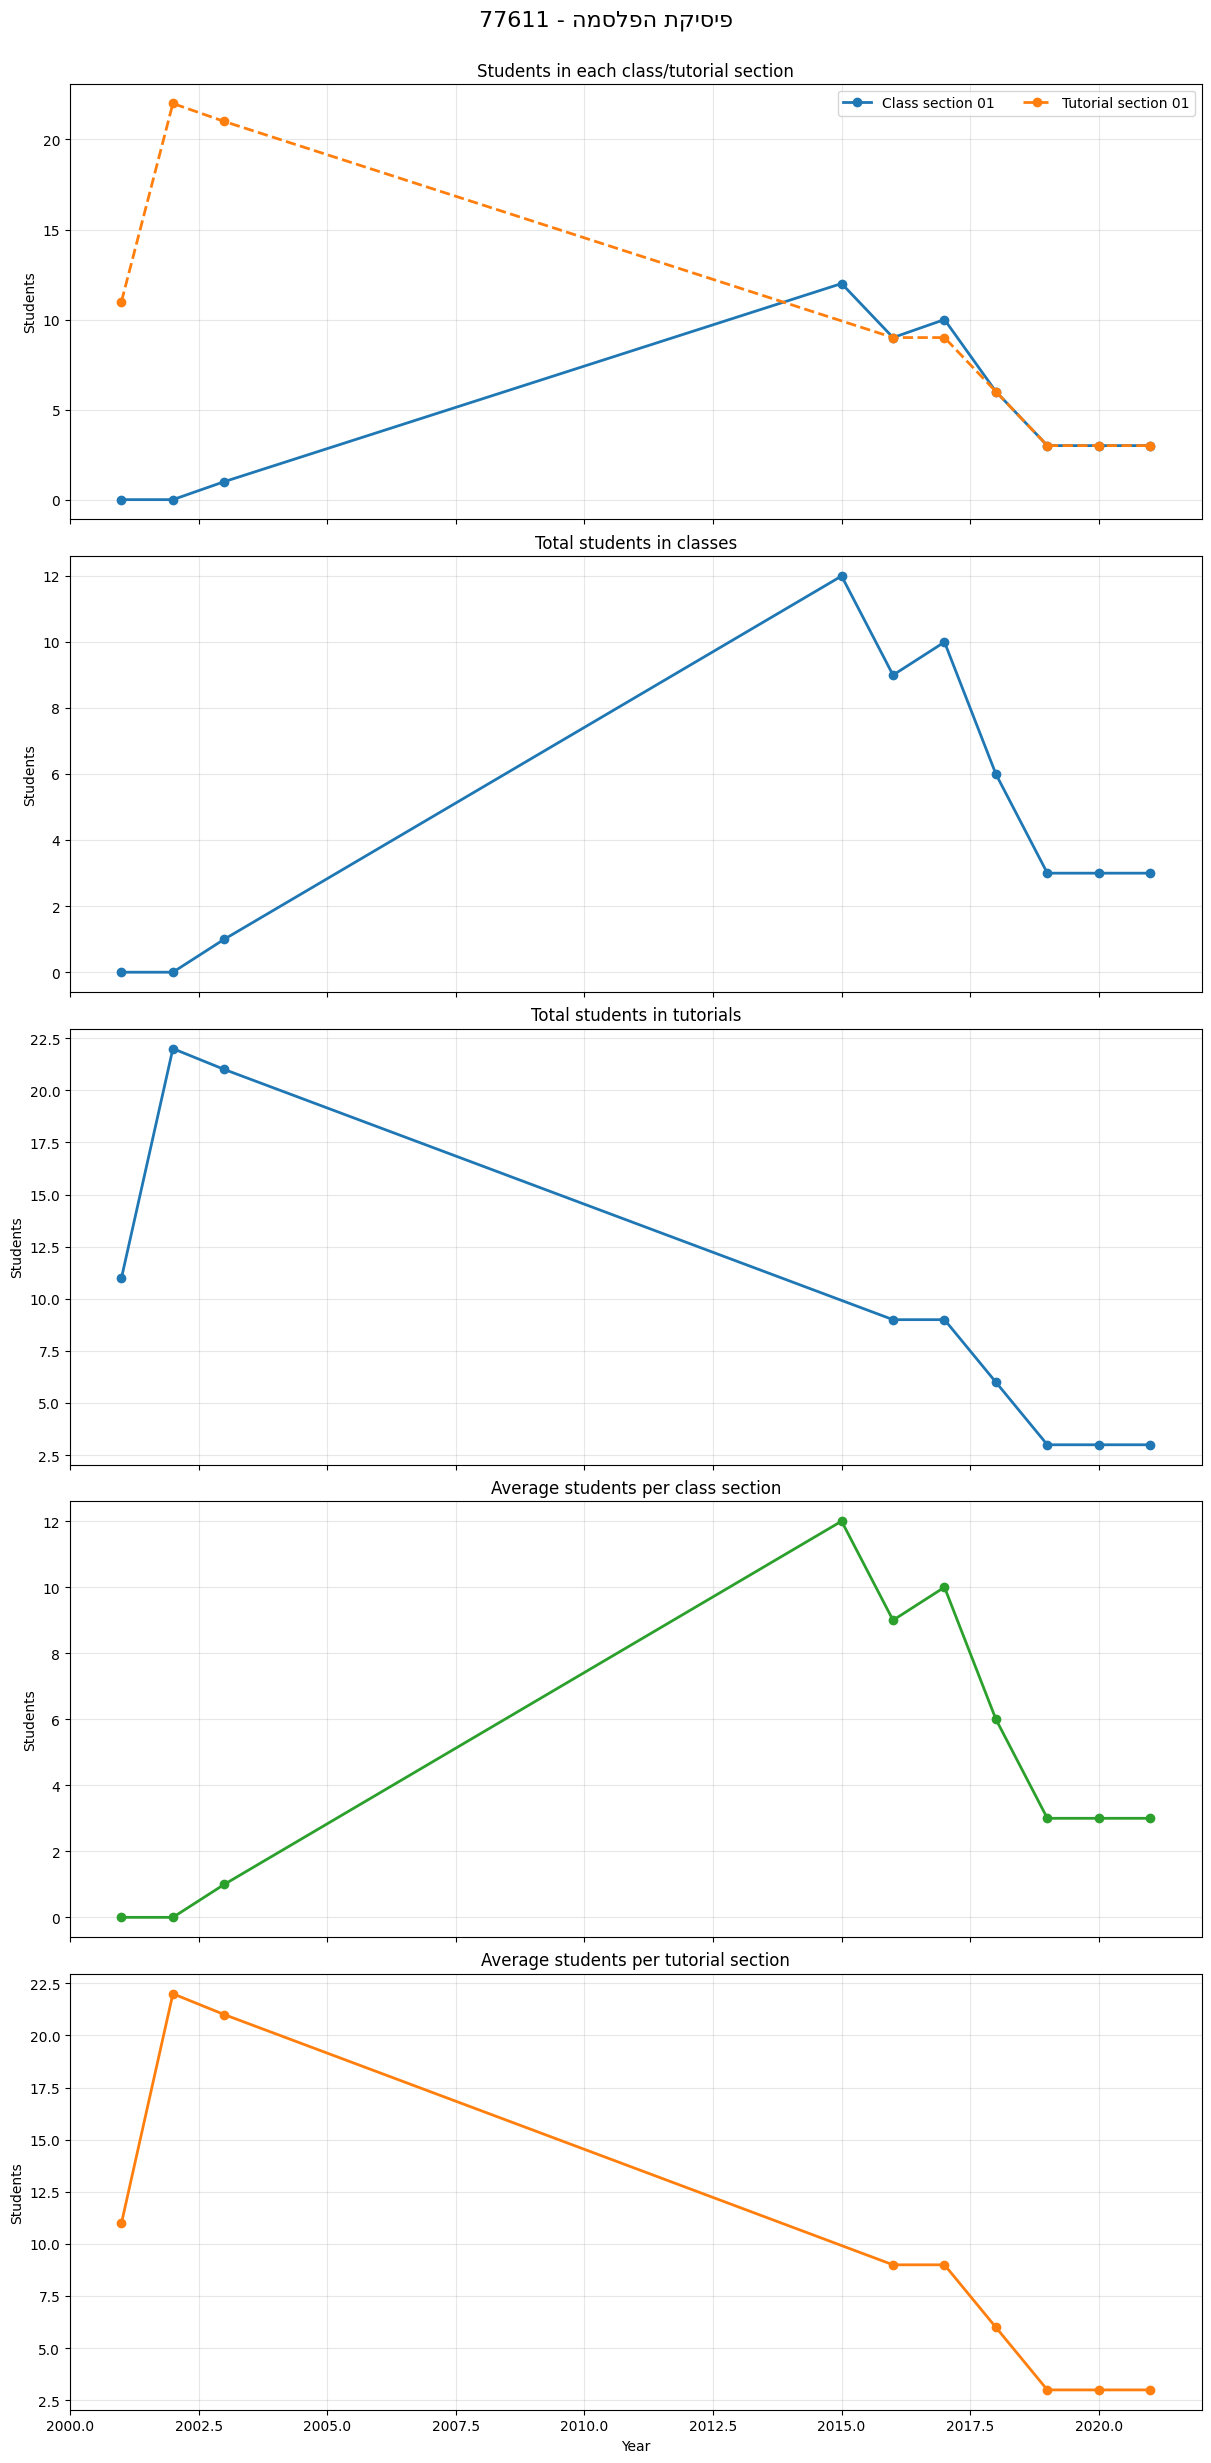

,full_code,course_name,"נ""ז","דוא""ל אוניברסיטאי של מרצים",זיהוי מרצים,זיהוי קורס,חוג נותן את הקורס,teacher_name,students,year,course_number,kind,section,kind_label
0,77611-1-01,פיסיקת הפלסמה,NaN,NaN,NaN,4197,פיסיקה,NaN,0,2001,77611,1,1,Class
1,77611-2-01,פיסיקת הפלסמה,NaN,NaN,NaN,4197,פיסיקה,NaN,11,2001,77611,2,1,Tutorial
2,77611-1-01,פיסיקת הפלסמה,NaN,NaN,NaN,4197,פיסיקה,NaN,0,2002,77611,1,1,Class
3,77611-2-01,פיסיקת הפלסמה,NaN,NaN,NaN,4197,פיסיקה,NaN,22,2002,77611,2,1,Tutorial
4,77611-1-01,פיסיקת הפלסמה,NaN,NaN,NaN,4197,פיסיקה,NaN,1,2003,77611,1,1,Class


,year,kind_label,total_students,sections,average_students_per_section
0,2001,Class,0,1,0.0
1,2001,Tutorial,11,1,11.0
2,2002,Class,0,1,0.0
3,2002,Tutorial,22,1,22.0
4,2003,Class,1,1,1.0
5,2003,Tutorial,21,1,21.0
6,2015,Class,12,1,12.0
7,2016,Class,9,1,9.0
8,2016,Tutorial,9,1,9.0
9,2017,Class,10,1,10.0


In [100]:
history_77101, summary_77101 = plot_course_history("77611")

display(history_77101.head())
display(summary_77101)


## Multi-Course PDF Summary

The next helpers create one plot per course for every course whose cumulative class enrollment is above 40.

Each plot includes:
- average students per class section
- average students per tutorial section
- total students

`total students` is computed from the class sections, which is the closest available course-level enrollment measure without double-counting students across both classes and tutorials.


In [ ]:
def build_course_overview_metrics(
    data: pd.DataFrame = all_data,
    min_total_class_students: float = 40,
) -> pd.DataFrame:
    history = data.loc[data["kind"].isin(["1", "2"])].copy()

    class_yearly = (
        history.loc[history["kind"] == "1"]
        .groupby(["course_number", "year"], as_index=False)
        .agg(
            total_students=("students", "sum"),
            average_students_per_class=("students", "mean"),
        )
    )

    tutorial_yearly = (
        history.loc[history["kind"] == "2"]
        .groupby(["course_number", "year"], as_index=False)
        .agg(average_students_per_tutorial=("students", "mean"))
    )

    eligible_courses = (
        class_yearly.groupby("course_number", as_index=False)["total_students"]
        .sum()
        .rename(columns={"total_students": "class_students_all_years"})
    )
    eligible_courses = eligible_courses.loc[
        eligible_courses["class_students_all_years"] > min_total_class_students
    ]

    course_names = (
        history.dropna(subset=["course_name"])
        .sort_values(["course_number", "year"])
        .groupby("course_number", as_index=False)
        .first()[["course_number", "course_name"]]
    )

    metrics = class_yearly.merge(
        tutorial_yearly,
        on=["course_number", "year"],
        how="outer",
    )
    metrics = metrics.merge(eligible_courses, on="course_number", how="inner")
    metrics = metrics.merge(course_names, on="course_number", how="left")

    return metrics.sort_values(["course_number", "year"]).reset_index(drop=True)


def plot_course_overview(ax: plt.Axes, course_metrics: pd.DataFrame) -> None:
    course_number = course_metrics["course_number"].iloc[0]
    course_name = bidi_text(course_metrics["course_name"].dropna().iloc[0])

    ax.plot(
        course_metrics["year"],
        course_metrics["average_students_per_class"],
        marker="o",
        linewidth=2,
        color="tab:blue",
        label="Avg students per class",
    )
    ax.plot(
        course_metrics["year"],
        course_metrics["average_students_per_tutorial"],
        marker="o",
        linewidth=2,
        color="tab:orange",
        label="Avg students per tutorial",
    )
    ax.plot(
        course_metrics["year"],
        course_metrics["total_students"],
        marker="o",
        linewidth=2.5,
        color="tab:green",
        label="Total students",
    )
    ax.axhline(40, color="black", linestyle="--", linewidth=1.5, label="40 students")
    ax.set_title(f"{course_number} - {course_name}")
    ax.set_ylabel("Students")
    ax.grid(alpha=0.3)
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0,
        fontsize=8,
    )


def export_course_overview_pdf(
    metrics: pd.DataFrame,
    output_path: Path = SUMMARY_PDF_PATH,
    plots_per_page: int = 3,
    save_pdf: bool = True,
) -> Path | None:
    if not save_pdf:
        return None

    course_numbers = metrics["course_number"].drop_duplicates().tolist()

    with PdfPages(output_path) as pdf:
        for start in range(0, len(course_numbers), plots_per_page):
            page_courses = course_numbers[start : start + plots_per_page]
            fig, axes = plt.subplots(
                plots_per_page,
                1,
                figsize=(9.5, 10.5),
                constrained_layout=True,
            )
            if plots_per_page == 1:
                axes = [axes]

            for axis, course_number in zip(axes, page_courses):
                course_metrics = metrics.loc[metrics["course_number"] == course_number]
                plot_course_overview(axis, course_metrics)
                axis.set_xlabel("Year")

            for axis in axes[len(page_courses) :]:
                axis.set_visible(False)

            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    return output_path


course_overview_metrics = build_course_overview_metrics()
course_overview_metrics.head()


In [ ]:
SAVE_SUMMARY_PDF = True

summary_pdf_path = export_course_overview_pdf(
    course_overview_metrics,
    save_pdf=SAVE_SUMMARY_PDF,
)

if summary_pdf_path is None:
    print("Skipped PDF creation. Set SAVE_SUMMARY_PDF = True to export the file.")
else:
    print(f"Created {summary_pdf_path} for {course_overview_metrics['course_number'].nunique()} courses.")
summary_pdf_path


## Yearly Section Distributions

These plots use all courses in the dataset, without the `> 40` course filter.

The first two violins show the yearly distribution of course-level averages:
- average students per class, within each course and year
- average students per tutorial, within each course and year

The next two violins show the raw section-level distributions:
- students per class section
- students per tutorial section

The final plot shows the largest class section and the largest tutorial section in each year.

In the violin plots, the black line connects the yearly medians.


In [ ]:
def build_yearly_violin_distributions(
    kind: str,
    data: pd.DataFrame = all_data,
    average_over_courses: bool = True,
) -> tuple[list[int], list[list[float]]]:
    subset = data.loc[data["kind"] == kind, ["course_number", "year", "students"]].copy()
    if subset.empty:
        raise ValueError(f"No rows were found for kind={kind}.")

    if average_over_courses:
        subset = (
            subset.groupby(["course_number", "year"], as_index=False)
            .agg(students=("students", "mean"))
        )

    years = sorted(subset["year"].unique())
    distributions = [
        subset.loc[subset["year"] == year, "students"].dropna().tolist()
        for year in years
    ]
    return years, distributions


def plot_yearly_section_violin(
    kind: str,
    data: pd.DataFrame = all_data,
    ax: plt.Axes | None = None,
    upper_quantile: float = 0.95,
    average_over_courses: bool = True,
) -> plt.Axes:
    years, distributions = build_yearly_violin_distributions(
        kind,
        data=data,
        average_over_courses=average_over_courses,
    )
    medians = [pd.Series(values).median() for values in distributions]
    yearly_upper_quantiles = [
        pd.Series(values).quantile(upper_quantile)
        for values in distributions
        if values
    ]
    y_upper = max(yearly_upper_quantiles)

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 5))

    style = {
        "1": {
            "color": "tab:blue",
            "avg_title": "Average students per class by course and year",
            "raw_title": "Students per class section by year",
            "avg_ylabel": "Average students per class",
            "raw_ylabel": "Students per class section",
        },
        "2": {
            "color": "tab:orange",
            "avg_title": "Average students per tutorial by course and year",
            "raw_title": "Students per tutorial section by year",
            "avg_ylabel": "Average students per tutorial",
            "raw_ylabel": "Students per tutorial section",
        },
    }[kind]

    violin = ax.violinplot(
        distributions,
        positions=years,
        widths=0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body in violin["bodies"]:
        body.set_facecolor(style["color"])
        body.set_edgecolor(style["color"])
        body.set_alpha(0.35)

    ax.plot(
        years,
        medians,
        color="black",
        marker="o",
        linewidth=2,
        label="Median",
    )
    for year, median in zip(years, medians):
        label = f"{median:.1f}".rstrip("0").rstrip(".")
        ax.annotate(
            label,
            (year, median),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=10,
            color="red",
            fontweight="bold",
            zorder=10,
        )
    ax.set_title(style["avg_title"] if average_over_courses else style["raw_title"])
    ax.set_ylabel(style["avg_ylabel"] if average_over_courses else style["raw_ylabel"])
    ax.set_xlabel("Year")
    ax.set_xticks(years)
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, y_upper)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

    return ax


def plot_yearly_section_maxima(
    data: pd.DataFrame = all_data,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    maxima = (
        data.loc[data["kind"].isin(["1", "2"]), ["year", "kind", "students"]]
        .groupby(["year", "kind"], as_index=False)
        .agg(max_students=("students", "max"))
    )
    years = sorted(maxima["year"].unique())

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 5))

    for kind, color, label in [
        ("1", "tab:blue", "Largest class section"),
        ("2", "tab:orange", "Largest tutorial section"),
    ]:
        subset = maxima.loc[maxima["kind"] == kind].sort_values("year")
        ax.plot(
            subset["year"],
            subset["max_students"],
            marker="o",
            linewidth=2,
            color=color,
            label=label,
        )
        for year, max_students in zip(subset["year"], subset["max_students"]):
            ax.annotate(
                f"{max_students:.0f}",
                (year, max_students),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=10,
                color="red",
                fontweight="bold",
                zorder=10,
            )

    ax.set_title("Largest class and tutorial sections by year")
    ax.set_ylabel("Students")
    ax.set_xlabel("Year")
    ax.set_xticks(years)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

    return ax


fig, axes = plt.subplots(5, 1, figsize=(14, 22), sharex=True, constrained_layout=True)
plot_yearly_section_violin("1", ax=axes[0], average_over_courses=True)
plot_yearly_section_violin("2", ax=axes[1], average_over_courses=True)
plot_yearly_section_violin("1", ax=axes[2], average_over_courses=False)
plot_yearly_section_violin("2", ax=axes[3], average_over_courses=False)
plot_yearly_section_maxima(ax=axes[4])
plt.show()


In [ ]:
def export_yearly_section_distributions_pdf(
    output_path: Path = DISTRIBUTION_PDF_PATH,
    save_pdf: bool = True,
) -> Path | None:
    if not save_pdf:
        return None

    fig, axes = plt.subplots(5, 1, figsize=(14, 22), sharex=True, constrained_layout=True)
    plot_yearly_section_violin("1", ax=axes[0], average_over_courses=True)
    plot_yearly_section_violin("2", ax=axes[1], average_over_courses=True)
    plot_yearly_section_violin("1", ax=axes[2], average_over_courses=False)
    plot_yearly_section_violin("2", ax=axes[3], average_over_courses=False)
    plot_yearly_section_maxima(ax=axes[4])

    with PdfPages(output_path) as pdf:
        pdf.savefig(fig, bbox_inches="tight")

    plt.close(fig)
    return output_path


SAVE_DISTRIBUTION_PDF = True

distribution_pdf_path = export_yearly_section_distributions_pdf(
    save_pdf=SAVE_DISTRIBUTION_PDF,
)

if distribution_pdf_path is None:
    print("Skipped distribution PDF creation. Set SAVE_DISTRIBUTION_PDF = True to export the file.")
else:
    print(f"Created {distribution_pdf_path}.")
distribution_pdf_path
